# Acne : 
* is a disorder of the hair follicles and oil glands (sebaceous glands). The oil glands secrete oils (sebum) to keep the skin moist. When the glands get clogged, it can lead to pimples and cysts. Acne is very common.

* one of the most common skin disorders peaks in adolescence and early adulthood, affecting around 85% of people between the ages of 12 and 24. Though it is often thought of as a teenage problem, acne can occur in people of any age.

# Some things that may trigger acne include:
* Hormonal changes that make the skin oilier. These may be related to puberty, menstrual periods, pregnancy, birth control pills, or stress. Greasy or oily cosmetic and hair products.

# Here are some acne-causing medical conditions to be aware of : 
* Polycystic ovary syndrome: Polycystic ovary syndrome (PCOS) occurs among females and commonly affects the menstrual cycle. 
* Cushing's syndrome. ...
* Androgen-secreting tumors.
* Cushing syndrome, CAH, androgen-secreting tumors, and acromegaly.
* Other nonendocrine diseases associated with acne include Apert syndrome, SAPHO syndrome, Behçet syndrome and PAPA syndrome .

# Organ can cause acne :
* The pancreas: produces insulin, which helps regulate blood sugar levels. If there's too much insulin or abnormal blood sugar levels in your body, it can cause acne on your nose and elsewhere on your face.

# treatment is best for acne?
* Antibiotics. For moderate to severe acne, you may need oral antibiotics to reduce bacteria. Usually the first choice for treating acne is a tetracycline (minocycline, doxycycline) or a macrolide (erythromycin, azithromycin).

# Clean skin : 
* Use skin serums. 
* Moisturise. 
* Protect your skin from harmful UV Rays. 
* Keep yourself hydrated and eat healthy. 
* Keep your stress in check. 
* Get enough sleep.
* Keep your skin clean. 
* Gently wash your face up to twice daily and after sweating.
* Choose the right skin care. 
* Shampoo regularly. 
* Stick to your treatment.


# For more informations :
[https://my.clevelandclinic.org/health/diseases/12233-acne](http://)

[https://www.pennmedicine.org/for-patients-and-visitors/patient-information/conditions-treated-a-to-z/acne](http://)


In [ ]:
%pip install ultralytics

  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.4 MB/s  0:00:00
Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl (37.9 MB)
Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 18.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 32.3 MB/s  0:00:01 eta 0:00:01
Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl (174 kB)
  Attempting uninstall: numpy90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [polars-runtime-32]
    Found existing installation: numpy 1.26.4━━━━━━━━━━━━━━━━━ 1/7 [polars-runtime-32]
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [polars-runtime-32]
      Successfully uninstalled nu

# Import Libraries :


In [4]:
#Libraries
import os
import pandas as pd
import cv2
from tqdm.notebook import tqdm
from PIL import Image
import cv2
import ultralytics
from ultralytics import YOLO
import numpy as np
import random

#tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import *
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import *
import keras_cv

#matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import seaborn as sns

#
import wandb
wandb.init(mode="disabled")
import shutil


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/quangthai/miniforge3/envs/bioinfo-tf/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/quangthai/miniforge3/envs/bioinfo-tf/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/quangthai/miniforge3/envs/bioinfo-tf/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/quangthai/miniforge3/envs/bioinfo-tf/lib/python3.10/site-packages/trait

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

# Data : 

In [5]:
train_path = 'data-2/train'
test_path = 'data-2/test'
val_path = 'data-2/valid'

In [6]:
train_images = os.listdir(train_path+'/images')
test_images = os.listdir(test_path+'/images')
val_images = os.listdir(val_path+'/images')
train_labels = os.listdir(train_path+'/labels')
test_labels = os.listdir(test_path+'/labels')
val_labels = os.listdir(val_path+'/labels')

num_train_images = len(train_images)
num_test_images = len(test_images)
num_val_images = len(val_images)
num_train_labels = len(train_labels)
num_test_labels = len(test_labels)
num_val_labels = len(val_labels)

print('images train: ',num_train_images,', images test: ', num_test_images,', images val: ', num_val_images, )
print('labels train: ',num_train_labels,', labels test: ', num_test_labels,', labels val: ', num_val_labels, )

images train:  823 , images test:  48 , images val:  56
labels train:  823 , labels test:  48 , labels val:  56


* The total number of images and classes :

In [7]:
def train_val_generators(training_dir, validation_dir,test_dir):

    train_datagen = ImageDataGenerator(rescale=1./255.)

    train_generator = train_datagen.flow_from_directory(directory=training_dir,
                                                        batch_size=16,
                                                        class_mode='categorical',
                                                        target_size=(150, 150))

    validation_datagen = ImageDataGenerator(rescale=1./255.)

    validation_generator = validation_datagen.flow_from_directory(directory=validation_dir,
                                                                  batch_size=16,
                                                                  class_mode='categorical',
                                                                  target_size=(150, 150))
    
    test_datagen = ImageDataGenerator(rescale=1./255.)

    test_generator = validation_datagen.flow_from_directory(directory=test_dir,
                                                                  batch_size=16,
                                                                  class_mode='categorical',
                                                                  target_size=(150, 150))


    return train_generator, validation_generator, test_generator

In [9]:
training_dir = 'data-2/train'
validation_dir = 'data-2/valid'
test_dir = 'data-2/test'
train_generator, validation_generator, test_generator = train_val_generators(training_dir,validation_dir,test_dir)

NameError: name 'ImageDataGenerator' is not defined

-------

# Show Images Data :

* Train images:

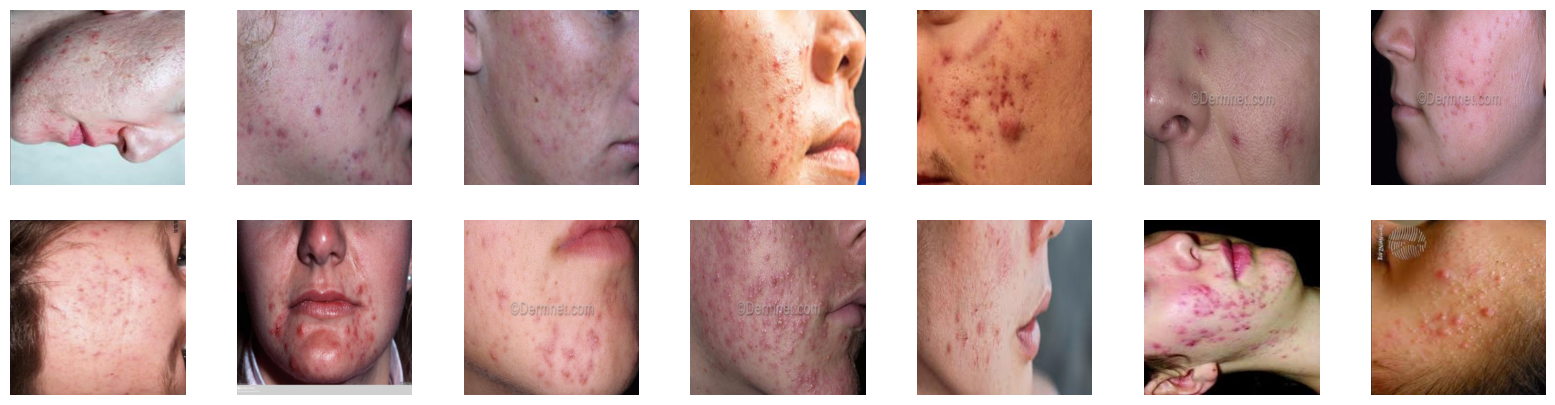

In [ ]:
plt.figure(figsize=(20,5))
for i, c in enumerate(np.random.randint(0, len(train_images), size=14), start=1):
    plt.subplot(2,7,i)
    im = plt.imread(train_path+'/images/'+train_images[c])
    plt.axis('off')
    plt.imshow(im, cmap='gray')

* Test images :

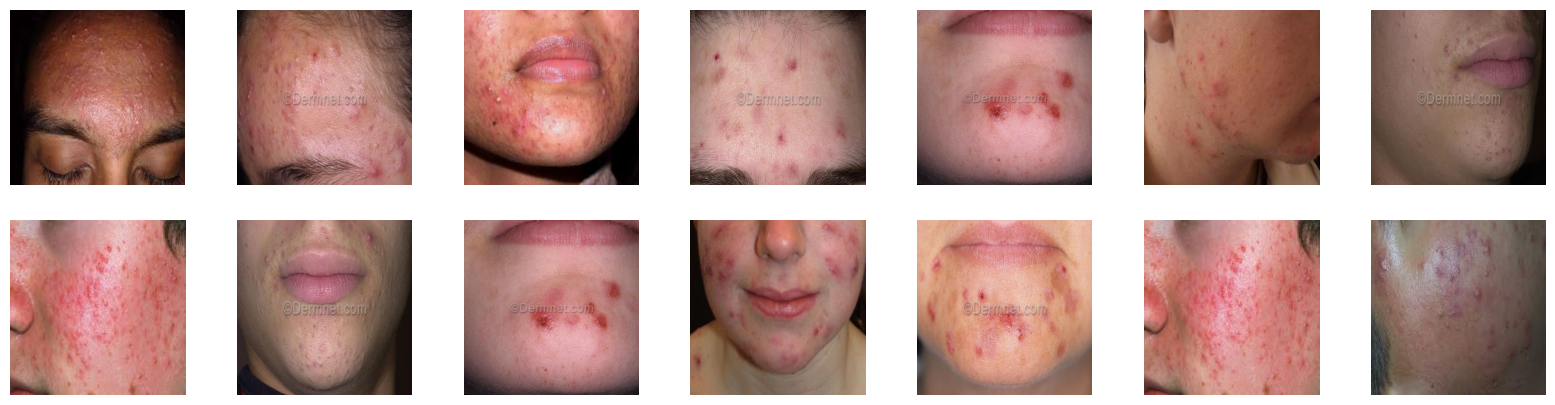

In [ ]:
plt.figure(figsize=(20,5))
for i, c in enumerate(np.random.randint(0, len(test_images), size=14), start=1):
    plt.subplot(2,7,i)
    im = plt.imread(test_path+'/images/'+test_images[c])
    plt.axis('off')
    plt.imshow(im, cmap='gray')

* Valid images :

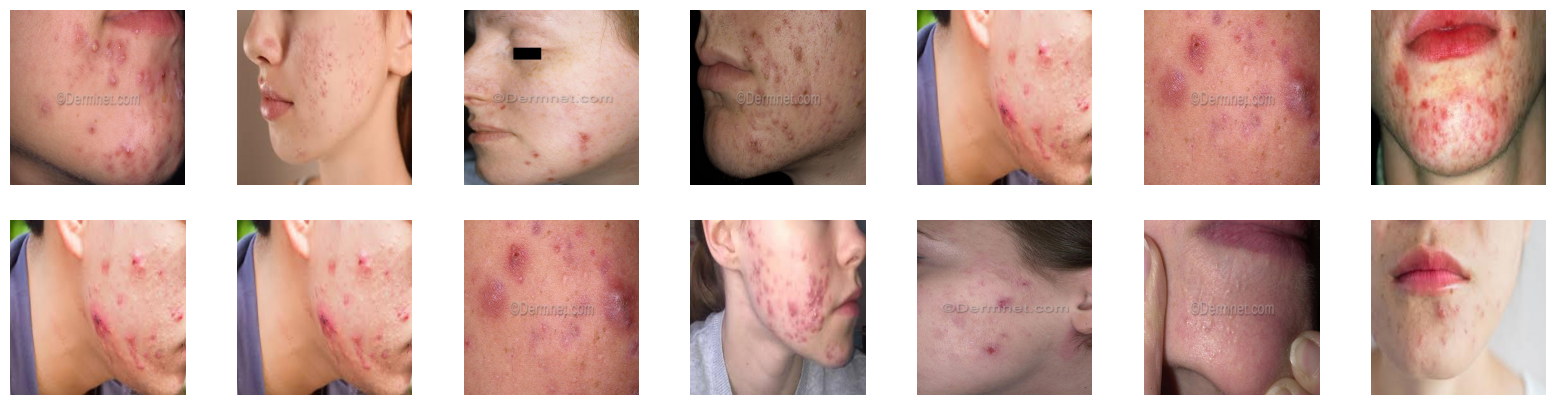

In [ ]:
plt.figure(figsize=(20,5))
for i, c in enumerate(np.random.randint(0, len(val_images), size=14), start=1):
    plt.subplot(2,7,i)
    im = plt.imread(val_path+'/images/'+val_images[c])
    plt.axis('off')
    plt.imshow(im, cmap='gray')

-------

# Model :

In [ ]:
model = YOLO("yolov8n.yaml")

# Train the Model :

In [ ]:
results = model.train(data=("data-2/data.yaml"),
                     epochs=200, imgsz=640)

Ultralytics YOLOv8.2.67 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/kaggle/input/acne-dataset-in-yolov8-format/data-2/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_lab

100%|██████████| 755k/755k [00:00<00:00, 23.1MB/s]
2024-07-28 13:03:50,565	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-07-28 13:03:51,038	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 6.25M/6.25M [00:00<00:00, 97.4MB/s]


AMP: checks passed ✅


...

    200/200      2.56G      1.561      1.035      1.188        109        640: 100%|██████████| 52/52 [00:08<00:00,  6.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  4.17it/s]

                   all         56        643      0.642      0.603      0.614      0.264



200 epochs completed in 0.565 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.67 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.23it/s]


                   all         56        643      0.592      0.608      0.622      0.272
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train


In [ ]:
# Get a test image from the test directory
test_image_files = os.listdir('data-2/test/images')
input_image = cv2.imread(os.path.join('data-2/test/images', test_image_files[0]))

In [ ]:
results = model.predict(source=input_image, conf=0.25)


0: 640x640 26 Acnes, 7.3ms
Speed: 1.7ms preprocess, 7.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
results[0].boxes.xyxy

tensor([[309.9696, 197.3065, 336.1187, 246.3778],
        [481.2338,  40.3451, 506.5334,  79.0624],
        [426.8088, 416.9664, 451.9061, 454.6910],
        [340.4304, 214.7255, 363.3142, 245.8225],
        [293.6423, 138.3787, 322.2421, 175.8954],
        [338.8173, 102.4676, 369.0998, 145.6677],
        [364.6338, 610.8780, 385.8630, 639.1057],
        [354.8251, 272.1992, 380.0905, 313.3281],
        [146.6546, 209.7107, 173.1768, 248.6931],
        [399.9963, 175.9385, 420.2350, 217.3467],
        [389.8195, 563.5060, 405.0960, 586.9499],
        [334.3329, 485.0927, 350.4718, 509.6802],
        [341.2557, 552.2661, 364.7339, 585.1443],
        [209.6862, 105.6563, 228.4102, 138.4004],
        [447.8510, 593.7899, 474.8295, 627.8804],
        [265.1168, 358.1147, 289.7462, 394.5403],
        [402.8405, 348.0559, 419.1042, 372.3030],
        [149.7551,  35.9090, 167.7649,  63.4734],
        [239.0404, 227.9818, 255.4382, 252.8949],
        [425.5880, 176.4888, 447.4661, 227.2617],


In [ ]:
results[0].boxes.conf

tensor([0.7664, 0.7310, 0.7174, 0.7125, 0.6668, 0.6649, 0.6411, 0.6084, 0.5987, 0.5981, 0.5876, 0.5140, 0.4706, 0.4653, 0.4629, 0.4616, 0.4379, 0.4160, 0.3537, 0.3367, 0.3342, 0.3190, 0.3171, 0.2903, 0.2752, 0.2681], device='cuda:0')

In [ ]:
results[0].boxes.cls

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')

In [ ]:
classNames = ["Acne"]

In [ ]:
%pip install cvzone
%pip install opencv-python

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Preparing metadata (setup.py) ... - \ done
  Created wheel for cvzone: filename=cvzone-1.6.1-py3-none-any.whl size=26297 sha256=a859c203bf7f53ea0a72235abc98e33d75d511bdbb12ced3b8c4fac7a82ed145
  Stored in directory: /root/.cache/pip/wheels/2c/9f/b3/92e945ac4a71bf727a92463f38155cc5a4fa49c5010b38ec4c
Successfully built cvzone


In [ ]:
import cv2
import cvzone
import math
from IPython.display import Image

In [ ]:

results = model(input_image, stream=True)
for r in results:
    boxes = r.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        w, h = x2-x1, y2-y1
        cvzone.cornerRect(input_image, (x1, y1, w, h))

        conf = math.ceil((box.conf[0]*100))/100

        cls = box.cls[0]
        name = classNames[int(cls)]

        cvzone.putTextRect(input_image, f'{name} 'f'{conf}', (max(0,x1), max(35,y1)), scale = 0.5)

cv2.imwrite('output.jpg', input_image)


0: 640x640 26 Acnes, 13.2ms
Speed: 3.7ms preprocess, 13.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


True

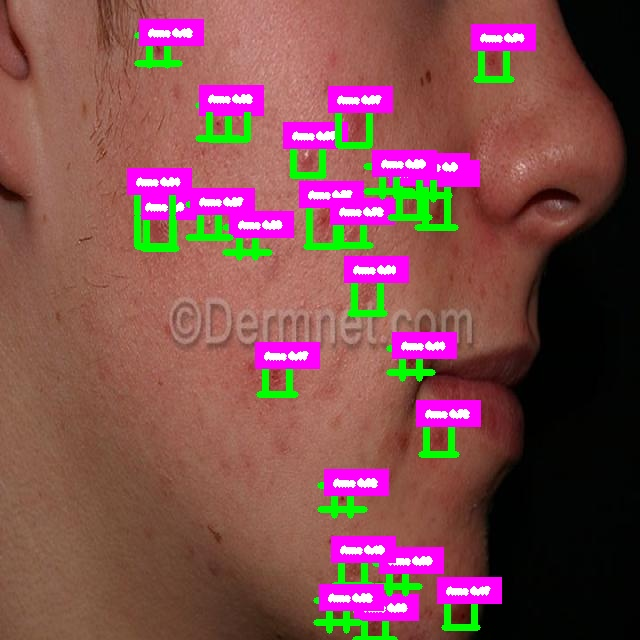

In [ ]:
Image("output.jpg")

# Results :
* Display results as images :

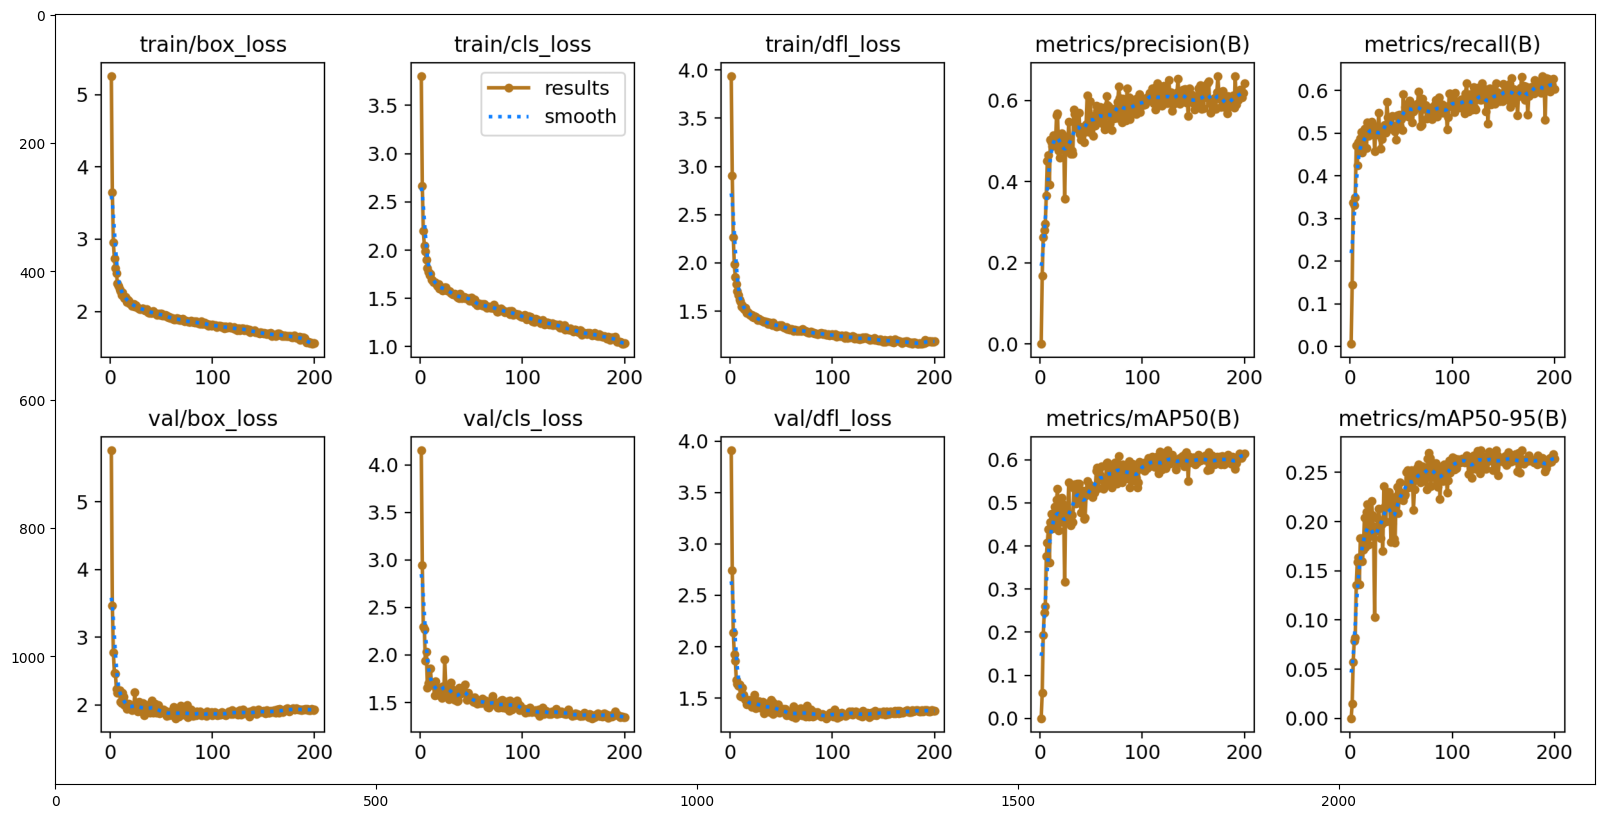

In [ ]:
plt.figure(figsize=(20, 10))
img = cv2.imread('runs/detect/train/results.png')
plt.imshow(img)
plt.show()

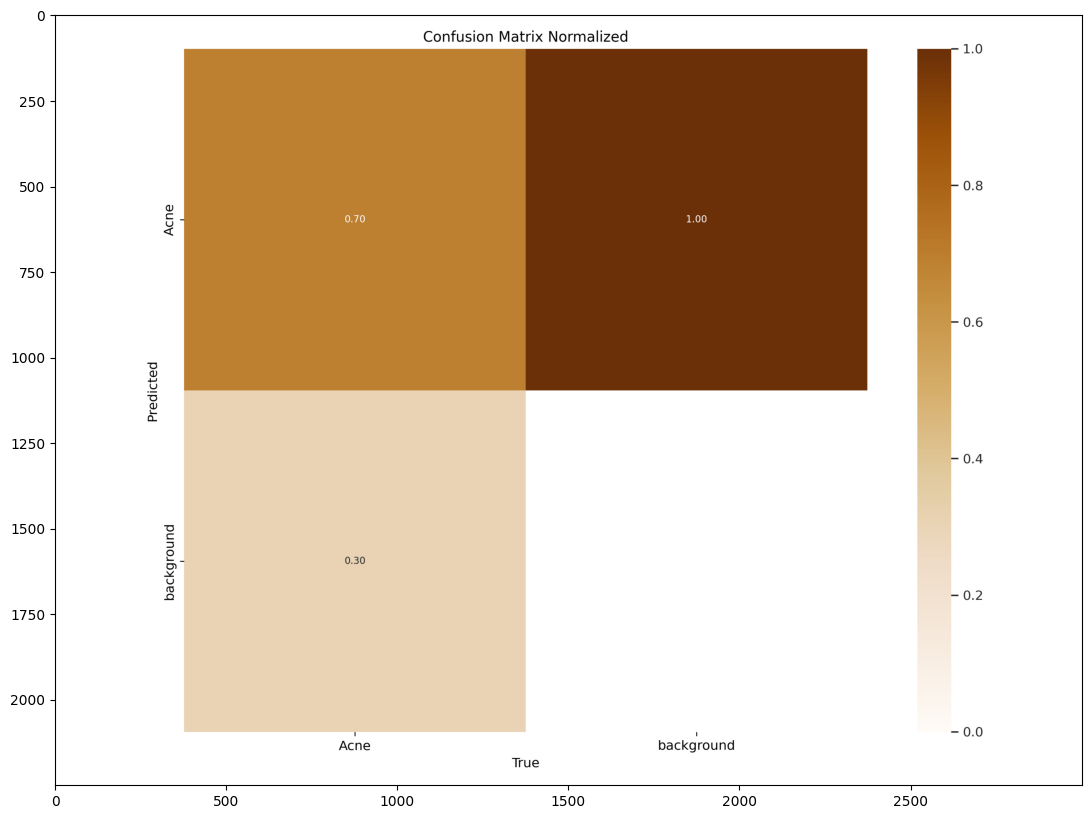

In [ ]:
plt.figure(figsize=(20, 10))
img = cv2.imread('runs/detect/train/confusion_matrix_normalized.png')
plt.imshow(img)
plt.show()

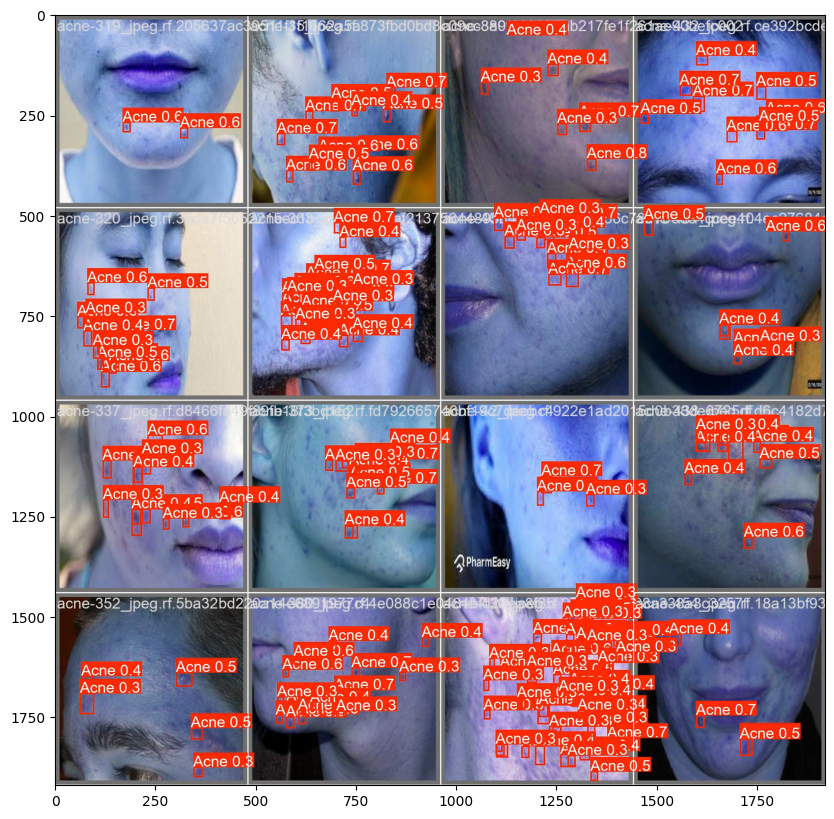

In [ ]:
plt.figure(figsize=(20, 10))
img = cv2.imread('runs/detect/train/val_batch1_pred.jpg')
plt.imshow(img)
plt.show()

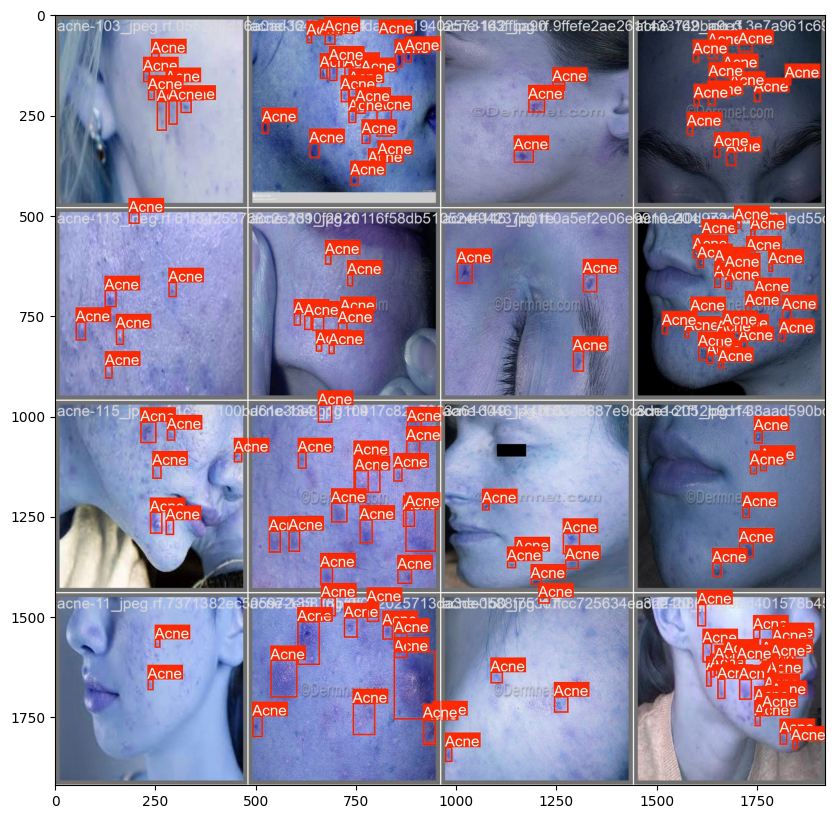

In [ ]:
plt.figure(figsize=(20, 10))
img = cv2.imread('runs/detect/train/val_batch0_labels.jpg')
plt.imshow(img)
plt.show()

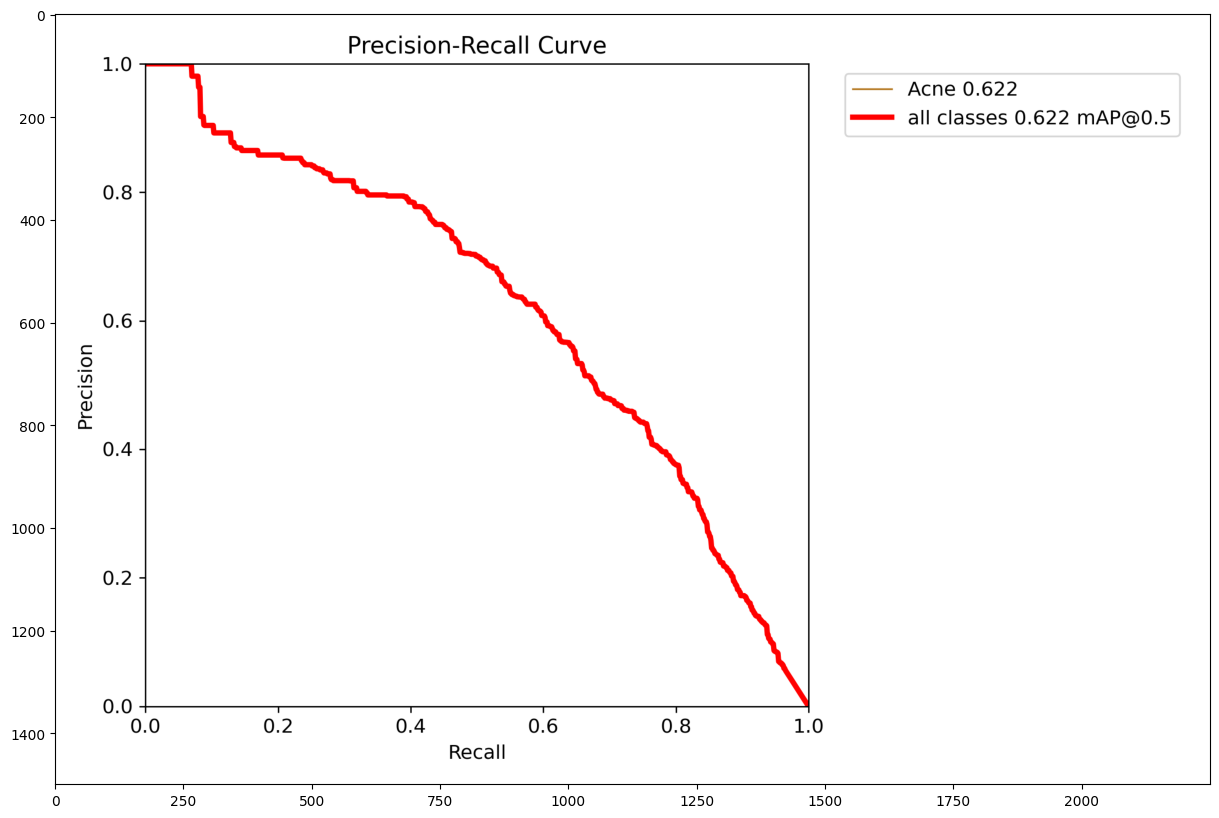

In [ ]:
plt.figure(figsize=(20, 10))
img = cv2.imread('runs/detect/train/PR_curve.png')
plt.imshow(img)
plt.show()

# Now we test the Model by using test images :

In [ ]:
# Function to perform ship detections
def Tumor_detect(img_path):
    
    # Read the image
    img = cv2.imread(img_path)

    # Pass the image through the detection model and get the result
    detect_result = model(img)

    # Plot the detections
    detect_img = detect_result[0].plot()
    
    # Convert the image to RGB format
    detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
    
    return detect_img

In [ ]:
import random


0: 640x640 17 Acnes, 11.6ms
Speed: 3.6ms preprocess, 11.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 16 Acnes, 7.7ms
Speed: 2.4ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 10 Acnes, 7.5ms
Speed: 1.9ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 20 Acnes, 7.7ms
Speed: 1.9ms preprocess, 7.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 Acnes, 7.5ms
Speed: 2.4ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 10 Acnes, 7.5ms
Speed: 1.8ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 Acnes, 7.5ms
Speed: 3.1ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 20 Acnes, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


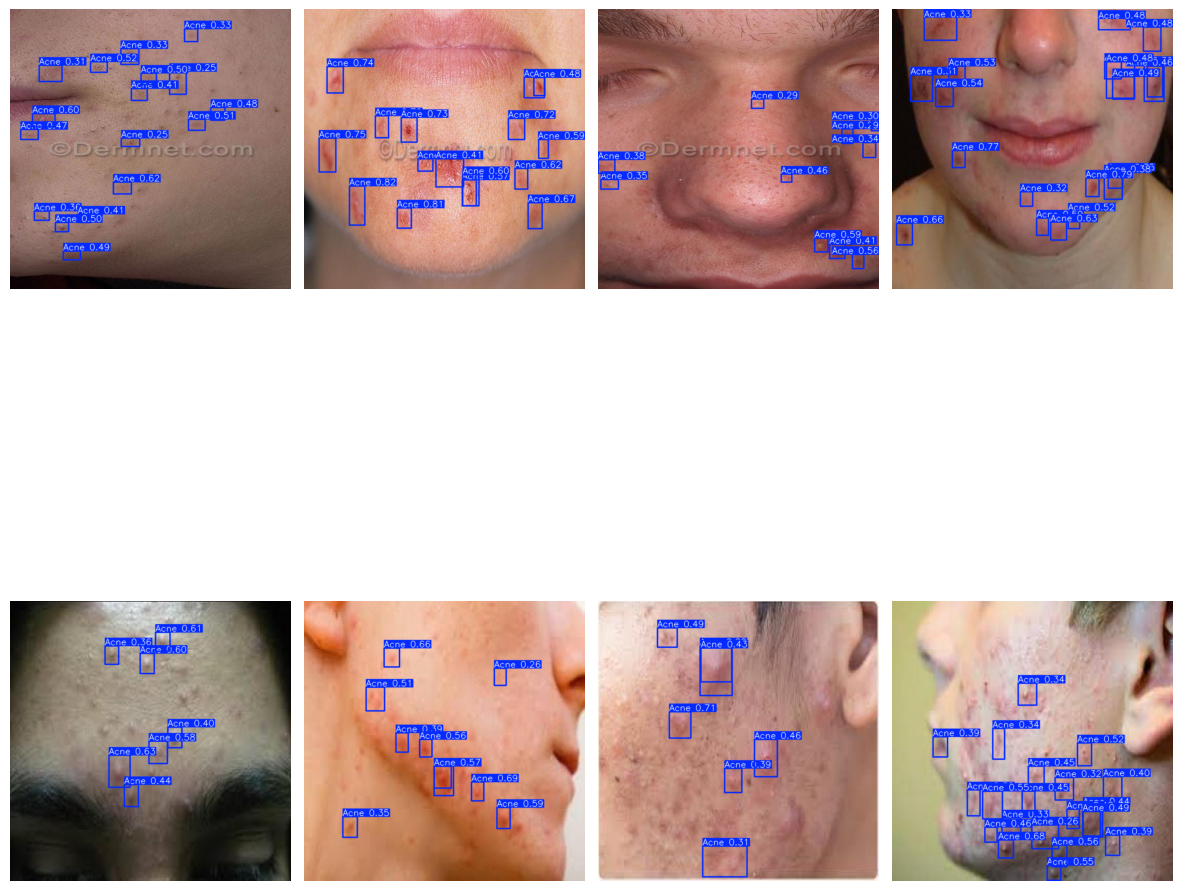

In [ ]:
# Define the directory where the custom images are stored
custom_image_dir = 'data-2/test/images'

# Get the list of image files in the directory
image_files = os.listdir(custom_image_dir)

# Select 16 random images from the list
selected_images = random.sample(image_files, 8)

# Create a figure with subplots for each image
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 15))

# Iterate over the selected images and plot each one
for i, img_file in enumerate(selected_images):
    
    # Compute the row and column index of the current subplot
    row_idx = i // 4
    col_idx = i % 4
    
    # Load the current image and run object detection
    img_path = os.path.join(custom_image_dir, img_file)
    detect_img = Tumor_detect(img_path)
    
    # Plot the current image on the appropriate subplot
    axes[row_idx, col_idx].imshow(detect_img)
    axes[row_idx, col_idx].axis('off')

# Adjust the spacing between the subplots
plt.subplots_adjust(wspace=0.05, hspace=0.05)

----------

# Thank you for reading ✨..
* I hope you have benefited from this notebook.
* Please post Upvote 👍🏻💯
* Best wishes 🌸..